ARTI308 - Machine Learning

# Assignment 2: Data Quality Assessment & Preprocessing

# Student Mental Health Dataset
- Sara Falah Alsahli
- 2220003277
- 8FA3

In [93]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

## 1. Load Dataset

In [94]:
pd.set_option("display.max_columns", None)

df = pd.read_csv("Student Mental health.csv")
df.head(10)

,Timestamp,Choose your gender,Age,What is your course?,Your current year of Study,What is your CGPA?,Marital status,Do you have Depression?,Do you have Anxiety?,Do you have Panic attack?,Did you seek any specialist for a treatment?
0,8/7/2020 12:02,Female,18.0,Engineering,year 1,3.00 - 3.49,No,Yes,No,Yes,No
1,8/7/2020 12:04,Male,21.0,Islamic education,year 2,3.00 - 3.49,No,No,Yes,No,No
2,8/7/2020 12:05,Male,19.0,BIT,Year 1,3.00 - 3.49,No,Yes,Yes,Yes,No
3,8/7/2020 12:06,Female,22.0,Laws,year 3,3.00 - 3.49,Yes,Yes,No,No,No
4,8/7/2020 12:13,Male,23.0,Mathemathics,year 4,3.00 - 3.49,No,No,No,No,No
5,8/7/2020 12:31,Male,19.0,Engineering,Year 2,3.50 - 4.00,No,No,No,Yes,No
6,8/7/2020 12:32,Female,23.0,Pendidikan islam,year 2,3.50 - 4.00,Yes,Yes,No,Yes,No
7,8/7/2020 12:33,Female,18.0,BCS,year 1,3.50 - 4.00,No,No,Yes,No,No
8,8/7/2020 12:35,Female,19.0,Human Resources,Year 2,2.50 - 2.99,No,No,No,No,No
9,8/7/2020 12:39,Male,18.0,Irkhs,year 1,3.50 - 4.00,No,No,Yes,Yes,No


## 2. Data Quality Assessment
### 2.1 Check Data Types

Data types must match the meaning of each column.

For example:

- `Timestamp` should be datetime
- `Age` should be numeric

In [95]:
df.dtypes

Timestamp                                        object
Choose your gender                               object
Age                                             float64
What is your course?                             object
Your current year of Study                       object
What is your CGPA?                               object
Marital status                                   object
Do you have Depression?                          object
Do you have Anxiety?                             object
Do you have Panic attack?                        object
Did you seek any specialist for a treatment?     object
dtype: object

- Explanation: The dataset contains different data types such as object and integer.
Some columns may need conversion to ensure proper analysis and preprocessing.

### 2.2 Convert Incorrect Data Types
We will convert:
- `Timestamp` to datetime format
- `Age` to numeric after removing currency symbols

In [96]:
# Convert Timestamp to datetime
df['Timestamp'] = pd.to_datetime(
    df['Timestamp'],
    dayfirst=True,
    errors='coerce'
)

# Convert Age to numeric
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')

# Check updated data types
print(df.dtypes)

Timestamp                                       datetime64[ns]
Choose your gender                                      object
Age                                                    float64
What is your course?                                    object
Your current year of Study                              object
What is your CGPA?                                      object
Marital status                                          object
Do you have Depression?                                 object
Do you have Anxiety?                                    object
Do you have Panic attack?                               object
Did you seek any specialist for a treatment?            object
dtype: object


- Explanation: Converting data types ensures consistency in the dataset.
Datetime conversion allows time-based analysis, while numeric conversion allows mathematical operations on Age.

## 3. Handling Missing Values
### 3.1 Detect Missing Values
Missing values reduce data quality and can affect model performance.

In [97]:
df.isna().sum()

Timestamp                                       23
Choose your gender                               0
Age                                              1
What is your course?                             0
Your current year of Study                       0
What is your CGPA?                               0
Marital status                                   0
Do you have Depression?                          0
Do you have Anxiety?                             0
Do you have Panic attack?                        0
Did you seek any specialist for a treatment?     0
dtype: int64

- Explanation: This step checks how many missing values exist in each column.

### 3.2 Demonstration: Introduce Artificial Missing Values
### Why?

The dataset already contains a small number of missing values. Additional artificial missing values are introduced for demonstration and preprocessing practice.

In [98]:
df_missing = df.copy()
df_missing.loc[0:5, 'Age'] = np.nan
df_missing.isna().sum()

Timestamp                                       23
Choose your gender                               0
Age                                              7
What is your course?                             0
Your current year of Study                       0
What is your CGPA?                               0
Marital status                                   0
Do you have Depression?                          0
Do you have Anxiety?                             0
Do you have Panic attack?                        0
Did you seek any specialist for a treatment?     0
dtype: int64

- Explanation: The dataset originally contained a few missing values. Additional missing values were intentionally introduced into the Age column to demonstrate different missing value handling strategies such as deletion, mean imputation, and median imputation.

In [99]:
print("Original shape: ",df.shape)
print("After removing some values: ",df_missing.shape)

Original shape:  (101, 11)
After removing some values:  (101, 11)


In [100]:
df_missing.head(10)

,Timestamp,Choose your gender,Age,What is your course?,Your current year of Study,What is your CGPA?,Marital status,Do you have Depression?,Do you have Anxiety?,Do you have Panic attack?,Did you seek any specialist for a treatment?
0,2020-07-08 12:02:00,Female,NaN,Engineering,year 1,3.00 - 3.49,No,Yes,No,Yes,No
1,2020-07-08 12:04:00,Male,NaN,Islamic education,year 2,3.00 - 3.49,No,No,Yes,No,No
2,2020-07-08 12:05:00,Male,NaN,BIT,Year 1,3.00 - 3.49,No,Yes,Yes,Yes,No
3,2020-07-08 12:06:00,Female,NaN,Laws,year 3,3.00 - 3.49,Yes,Yes,No,No,No
4,2020-07-08 12:13:00,Male,NaN,Mathemathics,year 4,3.00 - 3.49,No,No,No,No,No
5,2020-07-08 12:31:00,Male,NaN,Engineering,Year 2,3.50 - 4.00,No,No,No,Yes,No
6,2020-07-08 12:32:00,Female,23.0,Pendidikan islam,year 2,3.50 - 4.00,Yes,Yes,No,Yes,No
7,2020-07-08 12:33:00,Female,18.0,BCS,year 1,3.50 - 4.00,No,No,Yes,No,No
8,2020-07-08 12:35:00,Female,19.0,Human Resources,Year 2,2.50 - 2.99,No,No,No,No,No
9,2020-07-08 12:39:00,Male,18.0,Irkhs,year 1,3.50 - 4.00,No,No,Yes,Yes,No


### Strategy 1: Remove Records
This strategy removes records containing missing data.
It works well if the number of missing rows is small.

In [101]:
df_removed = df_missing.dropna()
df_removed.shape

(71, 11)

In [102]:
df_removed.isna().sum()

Timestamp                                       0
Choose your gender                              0
Age                                             0
What is your course?                            0
Your current year of Study                      0
What is your CGPA?                              0
Marital status                                  0
Do you have Depression?                         0
Do you have Anxiety?                            0
Do you have Panic attack?                       0
Did you seek any specialist for a treatment?    0
dtype: int64

The dataset now has fewer rows.
If only a small portion of data was missing, this method is acceptable.

However, removing too many rows can reduce model performance.

### Strategy 2: Mean Imputation

![Mean.png](img\Mean.png)

The mean represents the average value.
It is commonly used for normally distributed data.

In [103]:
df_missing.head(10)

,Timestamp,Choose your gender,Age,What is your course?,Your current year of Study,What is your CGPA?,Marital status,Do you have Depression?,Do you have Anxiety?,Do you have Panic attack?,Did you seek any specialist for a treatment?
0,2020-07-08 12:02:00,Female,NaN,Engineering,year 1,3.00 - 3.49,No,Yes,No,Yes,No
1,2020-07-08 12:04:00,Male,NaN,Islamic education,year 2,3.00 - 3.49,No,No,Yes,No,No
2,2020-07-08 12:05:00,Male,NaN,BIT,Year 1,3.00 - 3.49,No,Yes,Yes,Yes,No
3,2020-07-08 12:06:00,Female,NaN,Laws,year 3,3.00 - 3.49,Yes,Yes,No,No,No
4,2020-07-08 12:13:00,Male,NaN,Mathemathics,year 4,3.00 - 3.49,No,No,No,No,No
5,2020-07-08 12:31:00,Male,NaN,Engineering,Year 2,3.50 - 4.00,No,No,No,Yes,No
6,2020-07-08 12:32:00,Female,23.0,Pendidikan islam,year 2,3.50 - 4.00,Yes,Yes,No,Yes,No
7,2020-07-08 12:33:00,Female,18.0,BCS,year 1,3.50 - 4.00,No,No,Yes,No,No
8,2020-07-08 12:35:00,Female,19.0,Human Resources,Year 2,2.50 - 2.99,No,No,No,No,No
9,2020-07-08 12:39:00,Male,18.0,Irkhs,year 1,3.50 - 4.00,No,No,Yes,Yes,No


In [104]:
df_imputed_mean = df_missing.copy()

mean_value = df_imputed_mean['Age'].mean()
df_imputed_mean['Age'] = df_imputed_mean['Age'].fillna(mean_value)

df_imputed_mean.isna().sum()

Timestamp                                       23
Choose your gender                               0
Age                                              0
What is your course?                             0
Your current year of Study                       0
What is your CGPA?                               0
Marital status                                   0
Do you have Depression?                          0
Do you have Anxiety?                             0
Do you have Panic attack?                        0
Did you seek any specialist for a treatment?     0
dtype: int64

In [105]:
df_imputed_mean.head(10)

,Timestamp,Choose your gender,Age,What is your course?,Your current year of Study,What is your CGPA?,Marital status,Do you have Depression?,Do you have Anxiety?,Do you have Panic attack?,Did you seek any specialist for a treatment?
0,2020-07-08 12:02:00,Female,20.542553,Engineering,year 1,3.00 - 3.49,No,Yes,No,Yes,No
1,2020-07-08 12:04:00,Male,20.542553,Islamic education,year 2,3.00 - 3.49,No,No,Yes,No,No
2,2020-07-08 12:05:00,Male,20.542553,BIT,Year 1,3.00 - 3.49,No,Yes,Yes,Yes,No
3,2020-07-08 12:06:00,Female,20.542553,Laws,year 3,3.00 - 3.49,Yes,Yes,No,No,No
4,2020-07-08 12:13:00,Male,20.542553,Mathemathics,year 4,3.00 - 3.49,No,No,No,No,No
5,2020-07-08 12:31:00,Male,20.542553,Engineering,Year 2,3.50 - 4.00,No,No,No,Yes,No
6,2020-07-08 12:32:00,Female,23.000000,Pendidikan islam,year 2,3.50 - 4.00,Yes,Yes,No,Yes,No
7,2020-07-08 12:33:00,Female,18.000000,BCS,year 1,3.50 - 4.00,No,No,Yes,No,No
8,2020-07-08 12:35:00,Female,19.000000,Human Resources,Year 2,2.50 - 2.99,No,No,No,No,No
9,2020-07-08 12:39:00,Male,18.000000,Irkhs,year 1,3.50 - 4.00,No,No,Yes,Yes,No


- Explanation: Missing Age values were replaced using the average age of students.
This preserves the dataset size but may reduce variability.

### Strategy 3: Median Imputation

![median_formula_2.png](img/median_formula_2.png)
The median is more robust to outliers than the mean.
It is preferred for skewed data.

In [106]:
df_imputed_median = df_missing.copy()

median_value = df_imputed_median['Age'].median()
df_imputed_median['Age'] = df_imputed_median['Age'].fillna(median_value)

df_imputed_median.isna().sum()

Timestamp                                       23
Choose your gender                               0
Age                                              0
What is your course?                             0
Your current year of Study                       0
What is your CGPA?                               0
Marital status                                   0
Do you have Depression?                          0
Do you have Anxiety?                             0
Do you have Panic attack?                        0
Did you seek any specialist for a treatment?     0
dtype: int64

In [107]:
df_imputed_median.head(10)

,Timestamp,Choose your gender,Age,What is your course?,Your current year of Study,What is your CGPA?,Marital status,Do you have Depression?,Do you have Anxiety?,Do you have Panic attack?,Did you seek any specialist for a treatment?
0,2020-07-08 12:02:00,Female,19.0,Engineering,year 1,3.00 - 3.49,No,Yes,No,Yes,No
1,2020-07-08 12:04:00,Male,19.0,Islamic education,year 2,3.00 - 3.49,No,No,Yes,No,No
2,2020-07-08 12:05:00,Male,19.0,BIT,Year 1,3.00 - 3.49,No,Yes,Yes,Yes,No
3,2020-07-08 12:06:00,Female,19.0,Laws,year 3,3.00 - 3.49,Yes,Yes,No,No,No
4,2020-07-08 12:13:00,Male,19.0,Mathemathics,year 4,3.00 - 3.49,No,No,No,No,No
5,2020-07-08 12:31:00,Male,19.0,Engineering,Year 2,3.50 - 4.00,No,No,No,Yes,No
6,2020-07-08 12:32:00,Female,23.0,Pendidikan islam,year 2,3.50 - 4.00,Yes,Yes,No,Yes,No
7,2020-07-08 12:33:00,Female,18.0,BCS,year 1,3.50 - 4.00,No,No,Yes,No,No
8,2020-07-08 12:35:00,Female,19.0,Human Resources,Year 2,2.50 - 2.99,No,No,No,No,No
9,2020-07-08 12:39:00,Male,18.0,Irkhs,year 1,3.50 - 4.00,No,No,Yes,Yes,No


- Explanation: Missing values were replaced with the median age.
Median imputation is preferred when the data contains extreme values or skewness.

## 4. Handling Outliers
Outliers are extreme values that can distort models.
We will detect outliers using the IQR method.

![IQR.png](img/IQR.png)

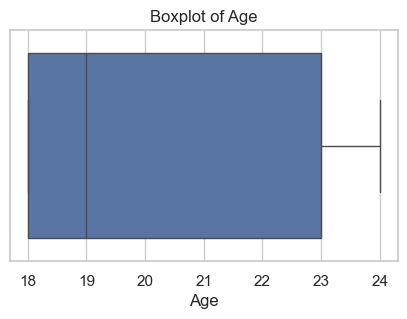

In [108]:
plt.figure(figsize=(5,3))
sns.boxplot(x=df['Age'])
plt.title("Boxplot of Age")
plt.show()

- Explanation: Points outside the whiskers may represent potential outliers.

### Detect Outliers using IQR
**Method: Interquartile Range (IQR)**

The IQR method defines outliers as values outside:

`Q1 - 1.5×IQR`  and  `Q3 + 1.5×IQR`

In [109]:
Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Age'] < lower) | (df['Age'] > upper)]
outliers.head(15)

,Timestamp,Choose your gender,Age,What is your course?,Your current year of Study,What is your CGPA?,Marital status,Do you have Depression?,Do you have Anxiety?,Do you have Panic attack?,Did you seek any specialist for a treatment?


- Explanation: No outliers were detected in the Age column using the IQR method.
This means all age values fall within the acceptable statistical range defined by the lower and upper bounds.

### Remove Outliers
We remove values outside the acceptable range.

In [110]:
df_no_outliers = df[
    ((df['Age'] >= lower) & (df['Age'] <= upper))
]

print("Original shape:", df.shape)

print("After removing outliers:", df_no_outliers.shape)

Original shape: (101, 11)
After removing outliers: (100, 11)


- Explanation: Although no statistical outliers were identified in the Age column, one row containing a missing value (NaN) was excluded during the filtering process. As a result, the dataset size decreased from 101 rows to 100 rows.

### Capping Outliers (Percentile Method)
Instead of removing outliers, we replace extreme values with percentile limits.

![percentile.png](img/percentile.png)

In [111]:
lower_cap = df['Age'].quantile(0.05)
upper_cap = df['Age'].quantile(0.95)

df_capped = df.copy()
df_capped['Age'] = df_capped['Age'].clip(lower_cap, upper_cap)

- Explanation: Outlier capping limits extreme values within a specified percentile range.
Although no major outliers were detected in the dataset, this technique is useful for reducing the impact of unusually large or small values without deleting records.

## 5. Data Transformation – Normalization
Normalization scales numerical features to a similar range.

We will normalize:
- Age

### Min-Max Normalization
Min-Max normalization scales values between 0 and 1.

In [112]:
df[['Age']].head()

,Age
0,18.0
1,21.0
2,19.0
3,22.0
4,23.0


In [113]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_scaled = df[['Age']].copy()

df_scaled[['Age']] = scaler.fit_transform(df_scaled)

df_scaled.head()

,Age
0,0.000000
1,0.500000
2,0.166667
3,0.666667
4,0.833333


- Explanation: 
Min-Max normalization scales Age values between 0 and 1.
The minimum value becomes 0, while the maximum value becomes 1.
This helps machine learning algorithms process features more effectively.

### Z-Score Normalization
Z-score standardization transforms the data so that:

- The mean of each feature becomes 0
- The standard deviation becomes 1

This is done by subtracting the mean and dividing by the standard deviation:

![zscore.png](img/zscore.png)

This method keeps the shape of the distribution but rescales it around zero.

In [114]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_standardized = df[['Age']].copy()

df_standardized[['Age']] = scaler.fit_transform(df_standardized)

df_standardized.head()

,Age
0,-1.018614
1,0.189229
2,-0.616000
3,0.591843
4,0.994457


- Explanation: Z-score normalization standardizes the data so that the mean becomes 0 and the standard deviation becomes 1.
Positive values represent observations above the mean, while negative values represent observations below the mean.

## Check Correlation Before Applying PCA

For PCA, we need numerical features.

We will create another numerical feature from CGPA categories.

## Convert CGPA Categories into Numeric Values

In [115]:
cgpa_mapping = {
    '0 - 1.99': 1,
    '2.00 - 2.49': 2,
    '2.50 - 2.99': 3,
    '3.00 - 3.49': 4,
    '3.50 - 4.00': 5
}

df_no_outliers = df_no_outliers.copy()

df_no_outliers['What is your CGPA?'] = (
    df_no_outliers['What is your CGPA?'].str.strip()
)

df_no_outliers['CGPA_numeric'] = (
    df_no_outliers['What is your CGPA?'].map(cgpa_mapping)
)

# remove rows with missing values
df_no_outliers = df_no_outliers.dropna(
    subset=['Age', 'CGPA_numeric']
)

df_no_outliers[['Age', 'CGPA_numeric']].head()

,Age,CGPA_numeric
0,18.0,4
1,21.0,4
2,19.0,4
3,22.0,4
4,23.0,4


- Explanation: CGPA categories were converted into numerical values so they can be used in correlation analysis and PCA.

## Standardize Features Before PCA

In [116]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_standardized = df_no_outliers[['Age', 'CGPA_numeric']].copy()

df_standardized[['Age', 'CGPA_numeric']] = scaler.fit_transform(
    df_standardized[['Age', 'CGPA_numeric']]
)

df_standardized.head()

,Age,CGPA_numeric
0,-1.018614,-0.352387
1,0.189229,-0.352387
2,-0.616000,-0.352387
3,0.591843,-0.352387
4,0.994457,-0.352387


- Explanation: Features were standardized before PCA because PCA is sensitive to feature scales.
Standardization ensures all variables contribute equally to the analysis.

## Correlation Heatmap

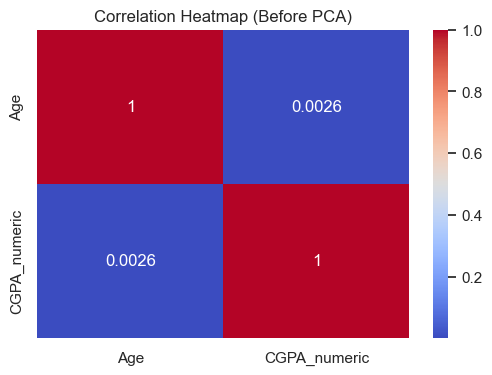

In [117]:
plt.figure(figsize=(6,4)) 
sns.heatmap( df_standardized[['Age', 'CGPA_numeric']].corr(), annot=True, cmap="coolwarm" ) 
plt.title("Correlation Heatmap (Before PCA)") 
plt.show()

Explanation: The heatmap shows the relationship between Age and CGPA.
- Correlation close to 1 → strong positive relationship
- Correlation close to -1 → strong negative relationship
- Correlation close to 0 → weak relationship

## 6. Data Reduction – Principal Component Analysis (PCA)

PCA reduces dimensionality while preserving important information.

In [118]:
from sklearn.decomposition import PCA 
X = df_standardized[['Age', 'CGPA_numeric']] 
pca = PCA(n_components=2) 
principal_components = pca.fit_transform(X) 
print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.50130434 0.49869566]


Explanation: 
- PCA reduces dimensionality while preserving the most important information in the dataset.
- The explained variance ratio shows how much information each principal component captures.
- Since missing values were removed during preprocessing, PCA can now be applied successfully.

## PCA Projection Visualization

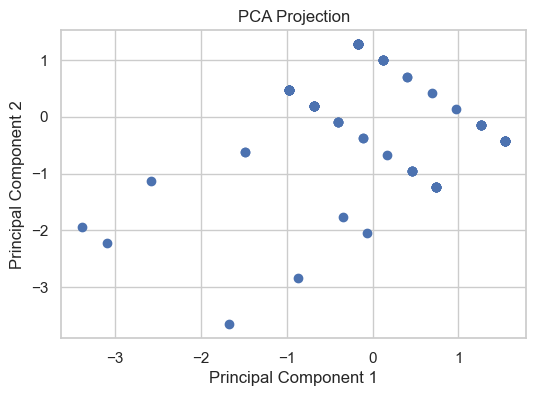

In [119]:
plt.figure(figsize=(6,4))

plt.scatter(
    principal_components[:,0],
    principal_components[:,1]
)

plt.title("PCA Projection")

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.show()

Explanation PCA projection visualizes the dataset in a reduced-dimensional space.
- Principal Component 1 captures the highest variance.
- Principal Component 2 captures the second highest variance

This helps simplify the dataset while preserving important patterns and relationships.

# Final Summary

In this assignment, we performed several preprocessing techniques on the Student Mental Health dataset:
- Identified and corrected data quality issues
- Detected and handled missing values
- Detected and handled outliers using IQR
- Applied Min-Max and Z-score normalization
- Applied PCA for dimensionality reduction

These preprocessing steps improve data quality and prepare the dataset for machine learning models.